In [1]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
os.chdir("/cosmos_storage/home/fgmaion/prob-bias/MTNG/src")
import merger_tree_tools as mgt

In [4]:
%load_ext autoreload
%autoreload 2

### Load the Zoom

In [161]:
#base = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/"
#base = "/cosmos_storage/data_sharing/MN5_resims/PM_1024/halos_10/hydro_output/"
#base = "/cosmos_storage/data_sharing/MN5_resims/PM_1536/halos_10/hydro_output/"
#base = "/cosmos_storage/data_sharing/MN5_resims/level4/PM_1024/new_ICs_halos_10/hydro_output/"
#base = "/cosmos_storage/data_sharing/MN5_resims/level1/PM_1024/halos_10/"
base = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

zoom = bacco.Simulation(basedir=base, halo_file="groups_010/fof_subhalo_tab_010", dm_file="snapdir_010/snapshot_010", sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False, tree_file="groups_010/subhalo_prog_010")

2024-07-22 14:50:34,781 bacco.sims : Initialising simulation Default
2024-07-22 14:50:34,782 bacco.sims : try /cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/snapdir_010/snapshot_010
2024-07-22 14:50:34,783 bacco.sims : Loading /cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/snapdir_010/snapshot_010


2024-07-22 14:50:34,802 bacco.sims : ...done in 0.00502 s
Exception ignored in: <function Simulation.__del__ at 0x2aac2e654550>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 580, in __del__
    self.cleanup()
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 10628, in cleanup
    self.Cosmology.cleanup()
AttributeError: 'Simulation' object has no attribute 'Cosmology'
Exception ignored in: <function Simulation.__del__ at 0x2aac2e654550>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 580, in __del__
    self.cleanup()
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 10628, in cleanup
    self.Cosmology.cleanup()
AttributeError: 'Simulation' object has no attribute 'Cosmology'
Exception ignored in: <function Simulation.__del__ at 0x2aac2e654550>
Traceback (most recent call last):
  File "/lscratch/fgmaion/baccogit/bacco/simulation.py", line 580, in __del__
    sel

### Load the Original Sim

In [17]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=264)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

2024-07-22 12:14:49,907 bacco.sims : Initialising simulation Default
2024-07-22 12:14:49,920 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-22 12:14:49,921 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-07-22 12:14:49,926 bacco.sims : Creating snapshot array from /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264 because: exists=True, newer=False
2024-07-22 12:14:49,941 bacco.sims : Warning: Empty snaplist.txt
2024-07-22 12:14:49,942 bacco.sims : ...done in 0.0189 s
2024-07-22 12:14:49,944 bacco.sims : Reading 98233510 items for GroupPos


2024-07-22 12:14:54,957 bacco.sims : Reading 90246895 items for SubhaloPos


### Let's work in a specific region

We will focus on one of the zoom halos

In [163]:
center = zoom.fof['halo_pos'][0]

2024-07-22 14:50:44,709 bacco.sims : Reading 5322 items for GroupPos


In [164]:
L_p = 10
z_slab = 10
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

shift = np.array([0,0,0]) * L_p/512 # n=0
#shift = np.array([44,50,13]) * L_p/512 # n=1
#shift = np.array([-3,50,-25]) * L_p/512 # n=2
#shift = np.array([50,65,60]) * L_p/512 # n=3
#shift = np.array([86,18,70]) * L_p/512 # n4

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]+shift[0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]+shift[0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]+shift[1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]+shift[1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]+shift[2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]+shift[1]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>50))[0]

In [168]:
zoom_sel = np.where( (zoom.dm['pos'][:,0]>(center[0]-L_p/2)) & (zoom.dm['pos'][:,0]<(center[0]+L_p/2)) &\
                     (zoom.dm['pos'][:,1]>(center[1]-L_p/2)) & (zoom.dm['pos'][:,1]<(center[1]+L_p/2)) &\
                     (zoom.dm['pos'][:,2]>(center[2]-z_slab/2)) & (zoom.dm['pos'][:,2]<(center[2]+z_slab/2)) )[0]

zoom_grid = bacco.statistics.compute_mesh(pos=zoom.dm['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

2024-07-22 14:51:27,165 bacco.sims : Read data for 462765/4415360 particles...
2024-07-22 14:51:27,209 bacco.sims : Read data for 462765/4415360 particles...
2024-07-22 14:51:27,212 bacco.sims : Read data for 563353/4415360 particles...
2024-07-22 14:51:27,257 bacco.sims : Read data for 563353/4415360 particles...
2024-07-22 14:51:27,259 bacco.sims : Read data for 585122/4415360 particles...
2024-07-22 14:51:27,314 bacco.sims : Read data for 585122/4415360 particles...
2024-07-22 14:51:27,316 bacco.sims : Read data for 564862/4415360 particles...


/cosmos_storage/data_sharing/tmp_resims/1080-A/level4/haloes_10/hydro_output/snapdir_010/snapshot_010.0.hdf5


2024-07-22 14:51:27,371 bacco.sims : Read data for 564862/4415360 particles...
2024-07-22 14:51:27,373 bacco.sims : Read data for 513876/4415360 particles...
2024-07-22 14:51:27,416 bacco.sims : Read data for 513876/4415360 particles...
2024-07-22 14:51:27,420 bacco.sims : Read data for 586189/4415360 particles...
2024-07-22 14:51:27,468 bacco.sims : Read data for 586189/4415360 particles...
2024-07-22 14:51:27,470 bacco.sims : Read data for 572623/4415360 particles...
2024-07-22 14:51:27,518 bacco.sims : Read data for 572623/4415360 particles...
2024-07-22 14:51:27,519 bacco.sims : Read data for 566570/4415360 particles...
2024-07-22 14:51:27,565 bacco.sims : Read data for 566570/4415360 particles...
2024-07-22 14:51:27,614 bacco.sims :  DM loading done in 0.451 sec


In [169]:
del sel_pos

shift = np.array([0,0,0]) * L_p/512 # n=0
#shift = np.array([44,50,13]) * L_p/512 # n=1
#shift = np.array([-3,50,-25]) * L_p/512 # n=2
#shift = np.array([80,35,60]) * L_p/512 # n=3
#shift = np.array([86,18,70]) * L_p/512 # n4

sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :]-shift[np.newaxis, :])/L_p * 512

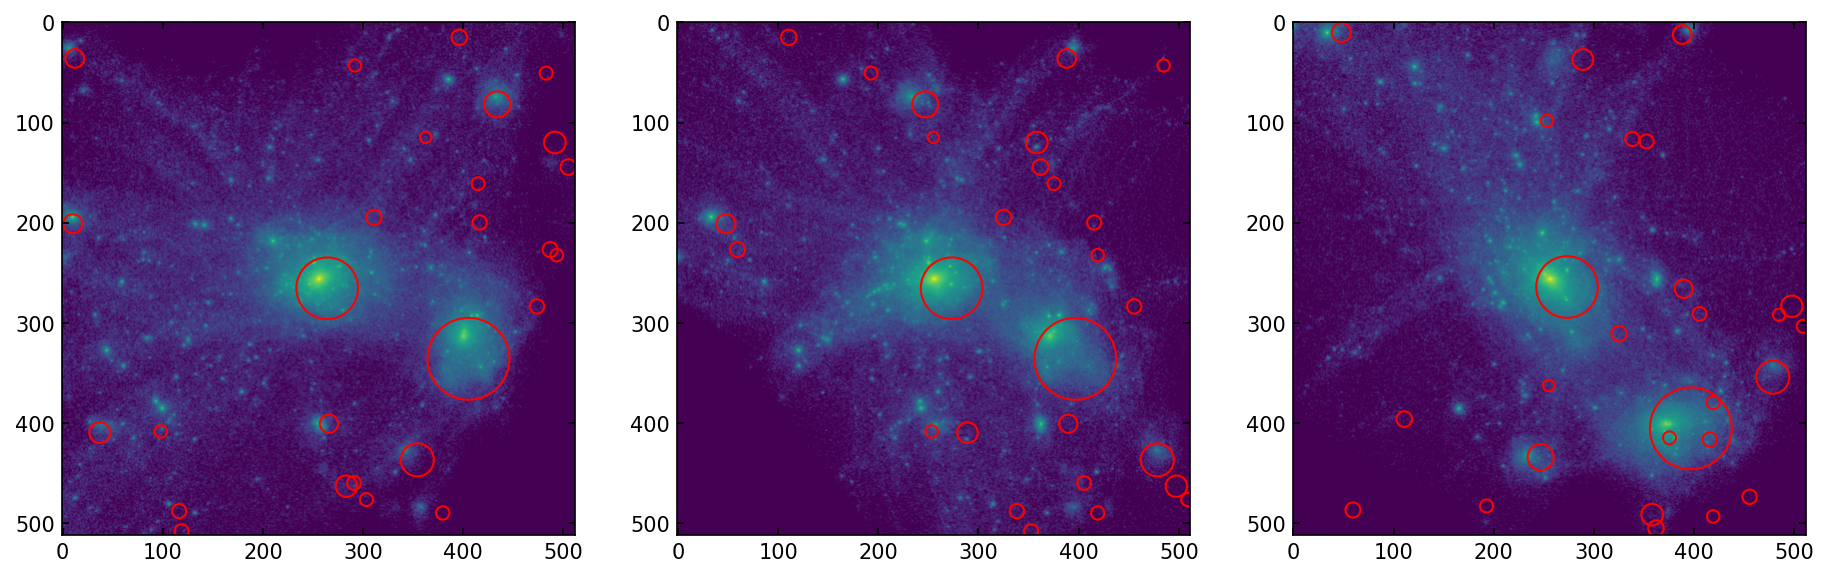

In [170]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(15,5))

ax[0].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)))
ax[1].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=1)))
ax[2].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=0)))

for i in range(sel_pos.shape[0]):
    circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[0].add_artist(circle)
    circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[1].add_artist(circle)
    circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
    ax[2].add_artist(circle)

In [150]:
mtng_dm.fof['halo_pos'][sel_10]

2024-07-22 14:37:20,218 bacco.sims : Reading 1780958 items for GroupPos


array([[158.25131 , 397.2463  , 461.02264 ],
       [483.60413 ,  56.266636, 183.8553  ],
       [ 64.90529 , 100.35018 , 265.82855 ],
       [139.22067 , 331.46042 , 265.98975 ],
       [460.11642 , 402.28793 ,  12.94096 ],
       [344.57736 ,  25.491707, 297.92514 ],
       [284.2199  , 271.80835 , 219.29013 ],
       [329.99432 , 491.3519  ,  42.82367 ],
       [295.1158  , 425.28735 ,  76.22827 ],
       [301.93088 , 346.14047 , 306.3655  ]], dtype=float32)

In [153]:
presel = np.where(mtng.fof['halo_m200b']>0)

In [154]:
hydro_dist, hydro_ind = bacco.utils.crossmatch(mtng_dm.fof['halo_pos'][sel_10], mtng.fof['halo_pos'][presel], max_distance=2, boxsize=500.000001)

In [155]:
hydro_dist

array([0.86574386, 1.24767528, 0.7706144 , 0.47072147,        inf,
       0.43939603,        inf, 1.11511093, 0.4647142 , 0.70210267])

In [115]:
sel_10 = [7763,
11153,
26801,
28348,
84870,
102096,
483812,
593575,
1663243,
1761238]

#### Cross-match halos in the this region

In [182]:
presel = np.where(mtng.fof['halo_m200b']>100)

In [194]:
dist, ind = bacco.utils.crossmatch(zoom.fof['halo_pos'], mtng.fof['halo_pos'][presel], max_distance=3, boxsize=500.000001)

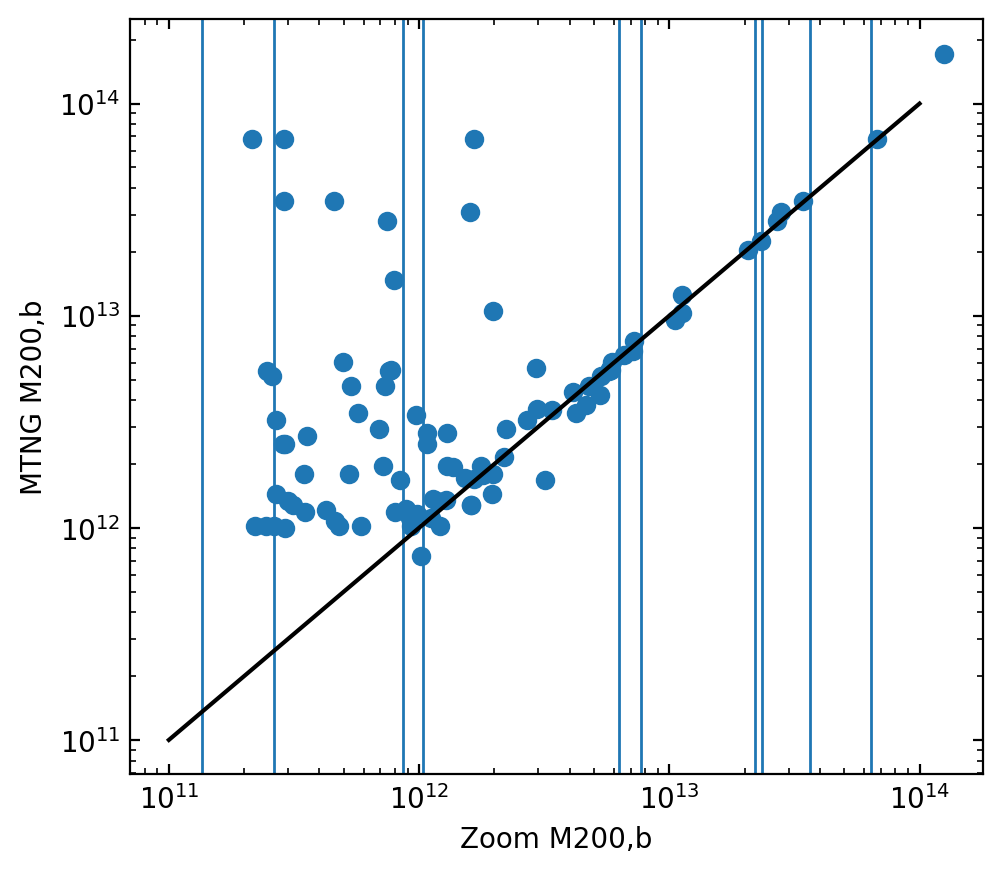

In [196]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Zoom M200,b')
ax.set_ylabel('MTNG M200,b')

for i in range(len(mtrue)):
    ax.axvline(mtrue[i], lw=1)

ax.plot(1e10*zoom.fof['halo_m200b'][:100], 1e10*mtng.fof['halo_m200b'][ind[:100]], marker='o', ls='')
#ax.plot(1e10*zoom.fof['halo_m200b'][:30], 1e10*mtng_dm.fof['halo_m200b'][ind[:30]], marker='o', ls='')

ax.plot(np.logspace(11,14,10), np.logspace(11,14,10), color='k')

In [100]:
part = zoom.get_halo_particles(0, relative=False)
zoom_grid = bacco.statistics.compute_mesh(pos=part - xmin[np.newaxis,:], box=L_p, ngrid=512)

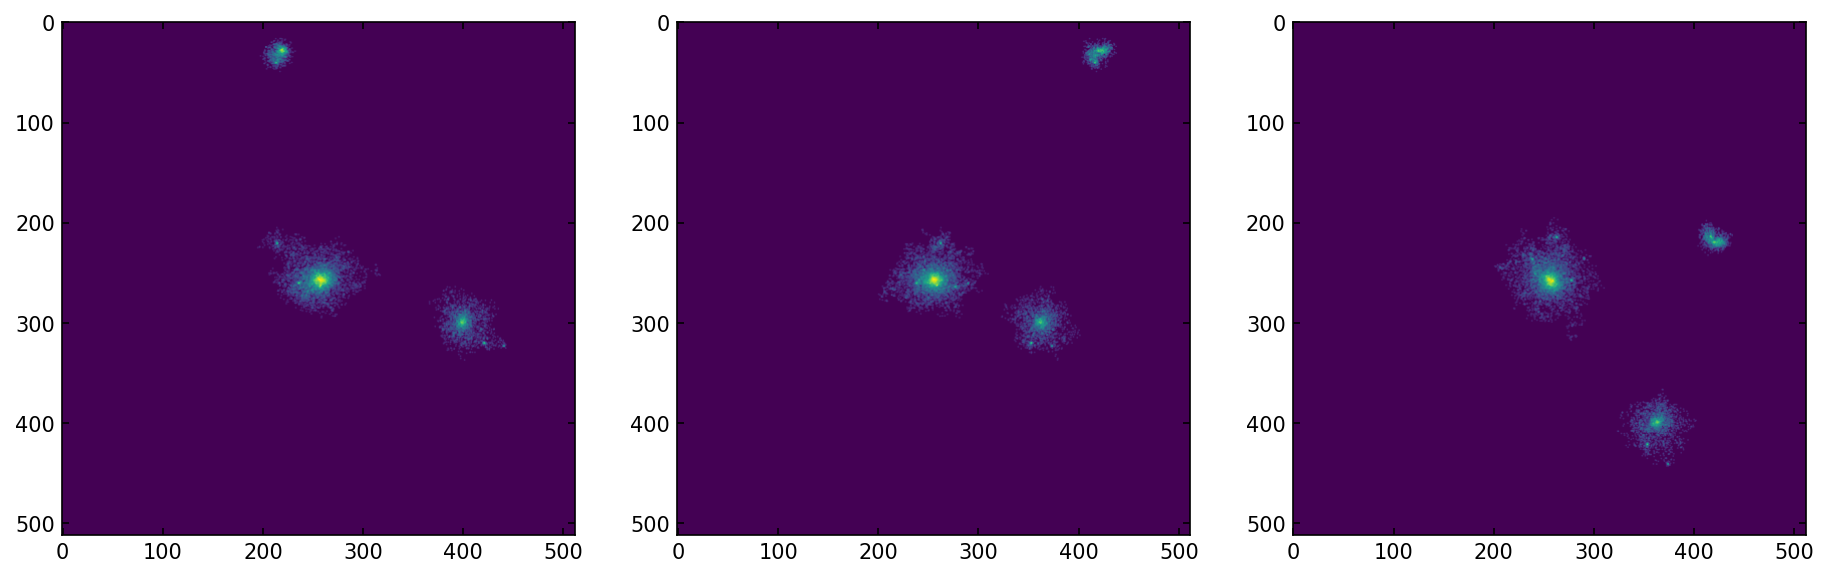

In [101]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(15,5))

ax[0].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=2)))
ax[1].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=1)))
ax[2].imshow(np.log10(1+np.sum(zoom_grid[0,:,:,:],axis=0)))

# for i in range(sel_pos.shape[0]):
#     circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
#     ax[0].add_artist(circle)
#     circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
#     ax[1].add_artist(circle)
#     circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
#     ax[2].add_artist(circle)

In [74]:
mtng.fof['halo_m200b'][ind[3]]

2256.3005

In [75]:
zoom.fof['halo_m200b'][3]

2157.5244

#### Let's get their central galaxy

In [33]:
mtng_ind_cen = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==True) )
mtng_ind_sat = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==False) )

/tmp/ipykernel_232797/1424730655.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  mtng_ind_cen = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==True) )
2024-07-22 12:21:23,401 bacco.sims : Reading 98233510 items for halo_firstsub


2024-07-22 12:21:58,944 bacco.sims : Reading 98233510 items for GroupNsubs
/tmp/ipykernel_232797/1424730655.py:2: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  mtng_ind_sat = np.where((mtng.sub['parent_halo']['index']==ind) &  (mtng.sub['central']==False) )


In [15]:
zoom_ind_cen = np.where((zoom.sub['parent_halo']['index']==0) &  (zoom.sub['central']==True) )
zoom_ind_sat = np.where((zoom.sub['parent_halo']['index']==0) &  (zoom.sub['central']==False) )

2024-07-10 17:14:14,318 bacco.sims : Reading the host halo properties of the subhaloes
2024-07-10 17:14:14,461 bacco.sims : Reading 5188 items for halo_firstsub
2024-07-10 17:14:14,479 bacco.sims : Reading 5188 items for GroupNsubs


### Now we have to load the trees

In [18]:
snap_0 = 264
depth = 100
files = np.arange(8)
Ntrees = 80

mtng_tree = mgt.tree(snap_0=snap_0, depth=depth, Ntrees=Ntrees) # class object containing methods related to the merger-trees
mtng_lentype = mtng_tree.get_subhalo_prop_hist(sub_id=mtng_ind_cen, name='SubhaloLenType')

In [19]:
snap_0 = 9
depth = 10
Ntrees = 8

tree = mgt.tree(snap_0=snap_0, depth=depth, Ntrees=Ntrees, treebase="/cosmos_storage/data_sharing/MN5_resims/halos_10/hydro_output/",\
                tree_format='arepo') # class object containing methods related to the merger-trees

lentype = tree.get_subhalo_prop_hist(sub_id=zoom_ind_cen, name='SubhaloLenType')


### Plot some properties

Text(0, 0.5, '$N$')

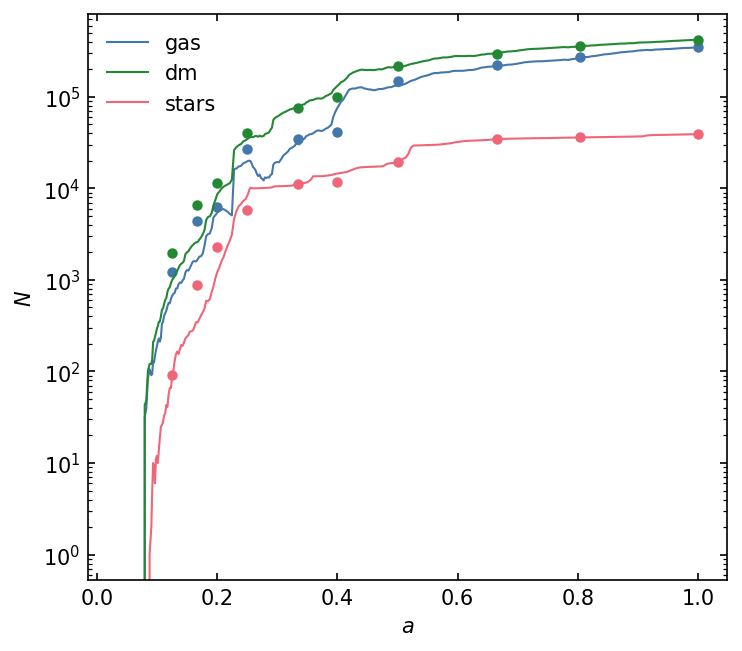

In [30]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']

ax.set_yscale('log')

ax.plot(tree.expfactor[::-1], lentype[0,:], color=colors[0], ls='', marker='o', ms=4)
ax.plot(tree.expfactor[::-1], lentype[1,:], color=colors[2], ls='', marker='o', ms=4)
ax.plot(tree.expfactor[::-1], lentype[2,:], color=colors[4], ls='', marker='o', ms=4)

ax.plot(mtng_tree.expfactor[::-1], mtng_lentype[0,:], color=colors[0], lw=1, ls='-', label='gas')
ax.plot(mtng_tree.expfactor[::-1], mtng_lentype[1,:], color=colors[2], lw=1, ls='-', label='dm')
ax.plot(mtng_tree.expfactor[::-1], mtng_lentype[2,:], color=colors[4], lw=1, ls='-', label='stars')

ax.legend()

ax.set_xlabel('$a$')
ax.set_ylabel('$N$')

In [213]:
with h5py.File('/cosmos_storage/simulations/MTNG/treedata/trees.0.hdf5', 'r') as f:
    print(f['TreeHalos'].keys())

<KeysViewHDF5 ['GroupNr', 'Group_M_Crit200', 'SnapNum', 'SubhaloHalfmassRad', 'SubhaloIDMostbound', 'SubhaloLen', 'SubhaloLenType', 'SubhaloMass', 'SubhaloNr', 'SubhaloPos', 'SubhaloSpin', 'SubhaloVel', 'SubhaloVelDisp', 'SubhaloVmax', 'SubhaloVmaxRad', 'TreeDescendant', 'TreeFirstDescendant', 'TreeFirstHaloInFOFgroup', 'TreeFirstProgenitor', 'TreeID', 'TreeIndex', 'TreeMainProgenitor', 'TreeNextDescendant', 'TreeNextHaloInFOFgroup', 'TreeNextProgenitor', 'TreeProgenitor']>


In [ ]:
moi_zoom = zoom.sub['subhalo_stellar_MOI'][zoom_ind_cen[0]][0]
moi_mtng = mtng.sub['subhalo_stellar_MOI'][mtng_ind_cen[0]][0]

In [ ]:
s_zoom = np.zeros((3,3))
s_zoom[0,0] = moi_zoom[0]
s_zoom[0,1] = moi_zoom[1]
s_zoom[0,2] = moi_zoom[2]
s_zoom[1,1] = moi_zoom[3]
s_zoom[1,2] = moi_zoom[4]
s_zoom[2,2] = moi_zoom[5]
s_zoom[1,0] = s_zoom[0,1]
s_zoom[2,0] = s_zoom[0,2]
s_zoom[1,2] = s_zoom[2,1]

s_mtng = np.zeros((3,3))
s_mtng[0,0] = moi_mtng[0]
s_mtng[0,1] = moi_mtng[1]
s_mtng[0,2] = moi_mtng[2]
s_mtng[1,1] = moi_mtng[3]
s_mtng[1,2] = moi_mtng[4]
s_mtng[2,2] = moi_mtng[5]
s_mtng[1,0] = s_mtng[0,1]
s_mtng[2,0] = s_mtng[0,2]
s_mtng[1,2] = s_mtng[2,1]

In [ ]:
np.trace(s_mtng@s_zoom) / np.sqrt( np.trace(s_mtng@s_mtng) * np.trace(s_zoom@s_zoom) )

0.9299541261822105

In [ ]:
eig_zoom

(array([0.83546849, 1.01563249, 1.08112812]),
 array([[ 0.91405544, -0.00697629,  0.40552927],
        [-0.01662907, -0.99965595,  0.0202846 ],
        [ 0.40524823, -0.02528482, -0.91385696]]))

In [ ]:
eig_mtng

(array([0.58306854, 1.69148092, 1.81810906]),
 array([[ 0.93635051,  0.02128272, -0.35042083],
        [ 0.08632803,  0.95355336,  0.28858875],
        [ 0.34028692, -0.30047137,  0.89102288]]))

In [ ]:
m_sub_zoom = 1e10 * zoom.sub['MassType'][zoom_sub_sel,4][i_clean]
m_sub_mtng = 1e10 * mtng.sub['MassType'][mtng_sub_sel,4][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

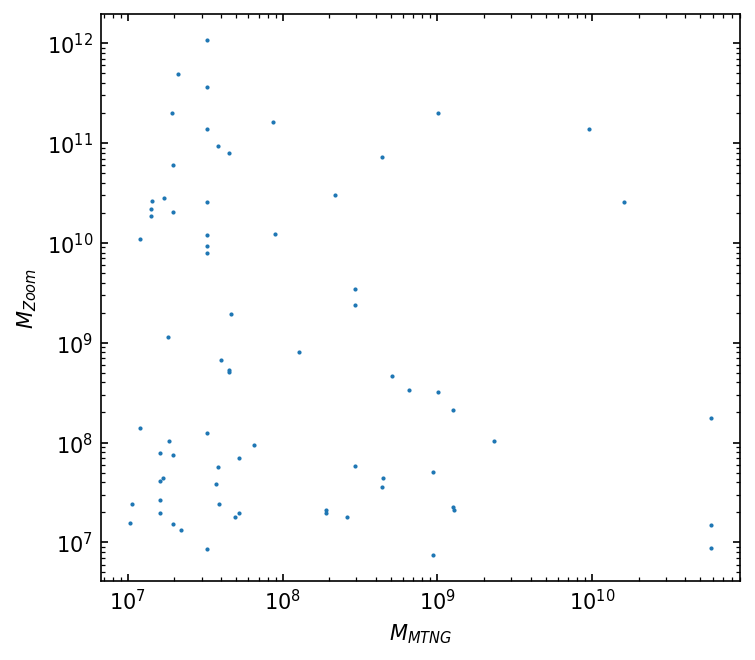

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_sub_mtng, m_sub_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')

### Cross-match FoF groups in the two

In [ ]:
zoom_sel = np.where(zoom.fof['halo_m200b']!=0)
mtng_sel = np.where(mtng.fof['halo_m200b']!=0)

In [ ]:
dist, ind = bacco.utils.crossmatch(zoom.fof['halo_pos'][zoom_sel], mtng.fof['halo_pos'][mtng_sel], max_distance=0.1, boxsize=500.000001)

In [ ]:
# clean the 
i_clean = np.where(dist!=np.inf)

In [ ]:
m_zoom = 1e10 * zoom.fof['halo_m200b'][zoom_sel][i_clean]
m_mtng = 1e10 * mtng.fof['halo_m200b'][mtng_sel][ind[i_clean]]

Text(0, 0.5, '$M_{Zoom}$')

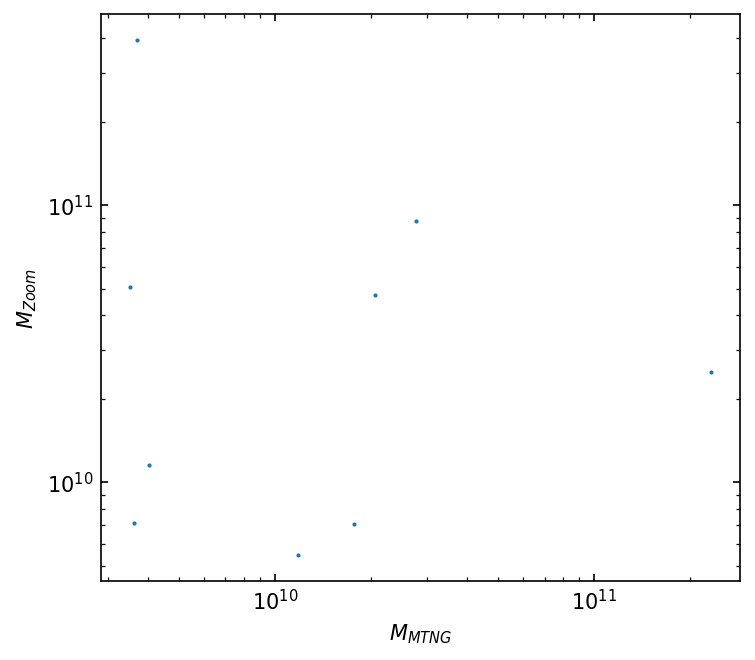

In [ ]:
fig, ax = plt.subplots(dpi=150, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(m_mtng, m_zoom, marker='o', ls='', ms=1)

ax.set_xlabel('$M_{MTNG}$')
ax.set_ylabel('$M_{Zoom}$')

In [39]:
dumps = np.array([-i*4*0.0081 for i in range(43)])

In [50]:
np.exp(dumps)

array([1.        , 0.96811926, 0.9372549 , 0.90737451, 0.87844674,
       0.8504412 , 0.82332851, 0.79708018, 0.77166867, 0.7470673 ,
       0.72325024, 0.70019249, 0.67786983, 0.65625884, 0.63533682,
       0.61508181, 0.59547254, 0.57648844, 0.55810956, 0.54031661,
       0.52309091, 0.50641439, 0.49026952, 0.47463936, 0.45950751,
       0.44485807, 0.43067566, 0.4169454 , 0.40365287, 0.39078412,
       0.37832563, 0.36626433, 0.35458755, 0.34328303, 0.33233892,
       0.3217437 , 0.31148628, 0.30155586, 0.29194204, 0.28263471,
       0.2736241 , 0.26490076, 0.25645553, 0.24827954])

In [51]:
z_dump =  1/np.exp(dumps) - 1

In [52]:
z_dump

array([0.        , 0.03293059, 0.06694561, 0.10208077, 0.13837294,
       0.17586024, 0.21458202, 0.25457893, 0.29589296, 0.33856748,
       0.38264731, 0.42817871, 0.47520948, 0.52378901, 0.57396828,
       0.6258    , 0.67933856, 0.73464018, 0.79176291, 0.85076673,
       0.91171358, 0.97466744, 1.03969441, 1.10686277, 1.17624301,
       1.24790799, 1.32193293, 1.39839557, 1.47737616, 1.55895763,
       1.64322563, 1.73026862, 1.82017799, 1.91304813, 2.00897654,
       2.10806392, 2.21041432, 2.31613517, 2.42533748, 2.53813588,
       2.6546488 , 2.77499856, 2.8993115 , 3.02771815])

In [48]:
dumps_2 = np.array([-42*4*0.0081 - 0.0162*4*i for i in range(15)])

In [46]:
z_dump_2 =  1/np.exp(dumps_2) - 1

In [47]:
z_dump_2

array([2.8993115 , 3.16035331, 3.43887071, 3.73603364, 4.05309032,
       4.39137255, 4.7523013 , 5.13739264, 5.54826415, 5.98664172,
       6.45436674, 6.9534039 , 7.4858494 , 8.0539398 , 8.66006136,
       9.3067601 , 9.99675248])

In [61]:
expfac = np.zeros(265)

for i in range(265):
    with h5py.File("/cosmos_storage/simulations/MTNG/single_files/file1/fof_subhalo_tab_{:03d}.1.hdf5".format(i)) as f:
        expfac[i] = f['Header'].attrs['Time']

In [98]:
with open("/cosmos_storage/home/fgmaion/MTNG_resims_snaps.txt", 'w') as f:
    for i in range(len(expfac[::5])):
        f.write(str(expfac[::5][i])+"\n")

In [78]:
1 / ( 1 + 1.5)

0.4

In [99]:
expfac

array([0.03298891, 0.03407837, 0.0352038 , 0.0363664 , 0.0375674 ,
       0.03880806, 0.04008969, 0.04141365, 0.04278133, 0.04419417,
       0.04565368, 0.04716139, 0.04871889, 0.05032782, 0.05198989,
       0.05370685, 0.05548052, 0.05731275, 0.0592055 , 0.06116075,
       0.06318058, 0.06526711, 0.06742255, 0.06964917, 0.07194933,
       0.07432544, 0.07678003, 0.07931568, 0.08193508, 0.08464097,
       0.08743623, 0.0903238 , 0.09180315, 0.09330673, 0.09483494,
       0.09638818, 0.09796685, 0.09957138, 0.1012022 , 0.10285972,
       0.10454439, 0.10625665, 0.10799695, 0.10976576, 0.11156354,
       0.11339076, 0.11524791, 0.11713548, 0.11905396, 0.12100386,
       0.1229857 , 0.125     , 0.12704729, 0.12912811, 0.13124301,
       0.13339255, 0.1355773 , 0.13779782, 0.14005472, 0.14234858,
       0.14468001, 0.14704962, 0.14945805, 0.15190592, 0.15439388,
       0.15692259, 0.15949272, 0.16210494, 0.16475995, 0.16745844,
       0.17020113, 0.17298874, 0.175822  , 0.17870167, 0.18162

In [89]:
1 / 0.11 - 1

8.090909090909092